In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

pd.set_option("display.max_columns", None)


In [2]:
core_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\core_cleaned.csv")
audio_df = pd.read_csv(r"D:\spotify\data\processed\cleaned\audio_features_cleaned.csv")

In [3]:
core_df["merge_key"] = (
    core_df["track_name"].str.lower().str.strip() + "_" +
    core_df["artist_name"].str.lower().str.strip()
)

audio_df["merge_key"] = (
    audio_df["track_name"].str.lower().str.strip() + "_" +
    audio_df["artist_name"].str.lower().str.strip()
)


In [4]:
merged_df = pd.merge(
    core_df,
    audio_df,
    on="merge_key",
    how="inner",
    suffixes=("_core", "_audio")
).drop_duplicates()


In [5]:
audio_features = [
    "danceability",
    "energy",
    "valence",
    "tempo",
    "loudness",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness"
]

feature_df = merged_df[audio_features + ["popularity"]].dropna()


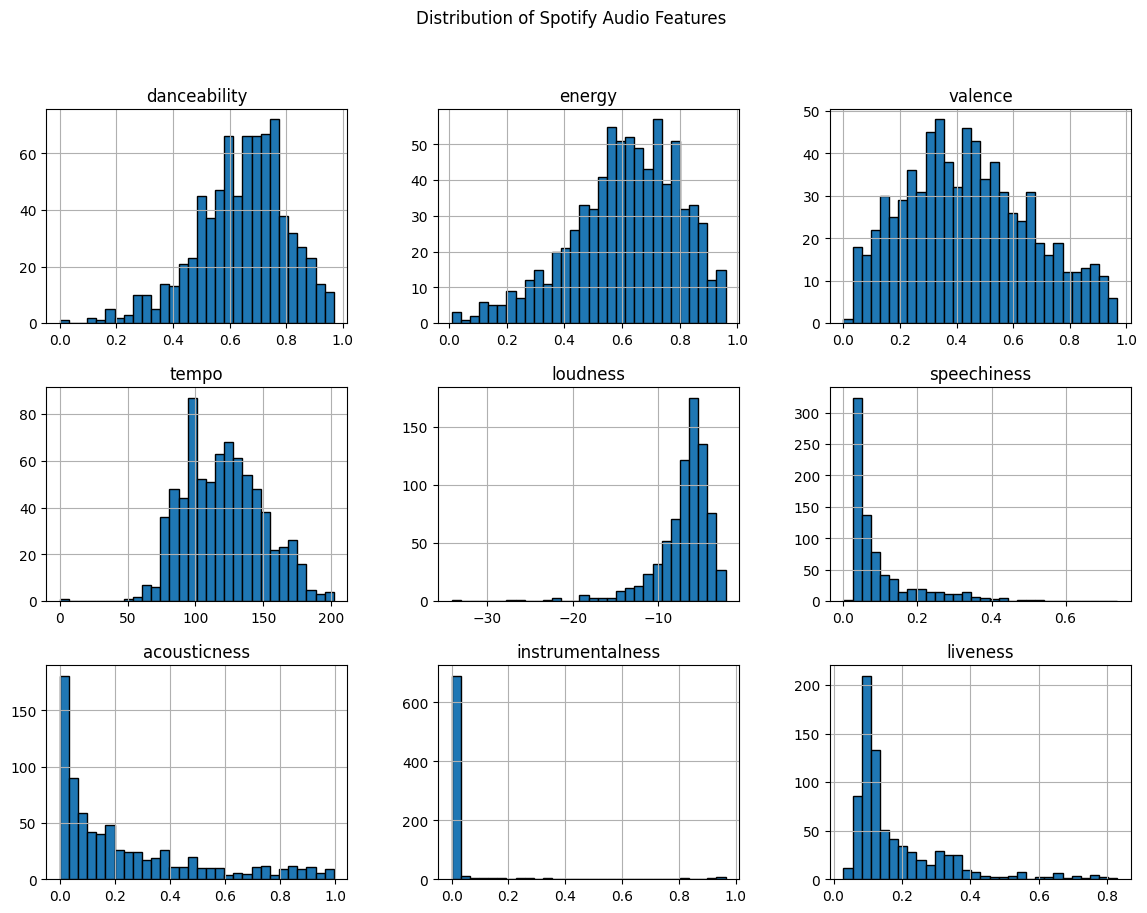

In [6]:
feature_df[audio_features].hist(
    figsize=(14,10),
    bins=30,
    edgecolor="black"
)
plt.suptitle("Distribution of Spotify Audio Features")
plt.show()


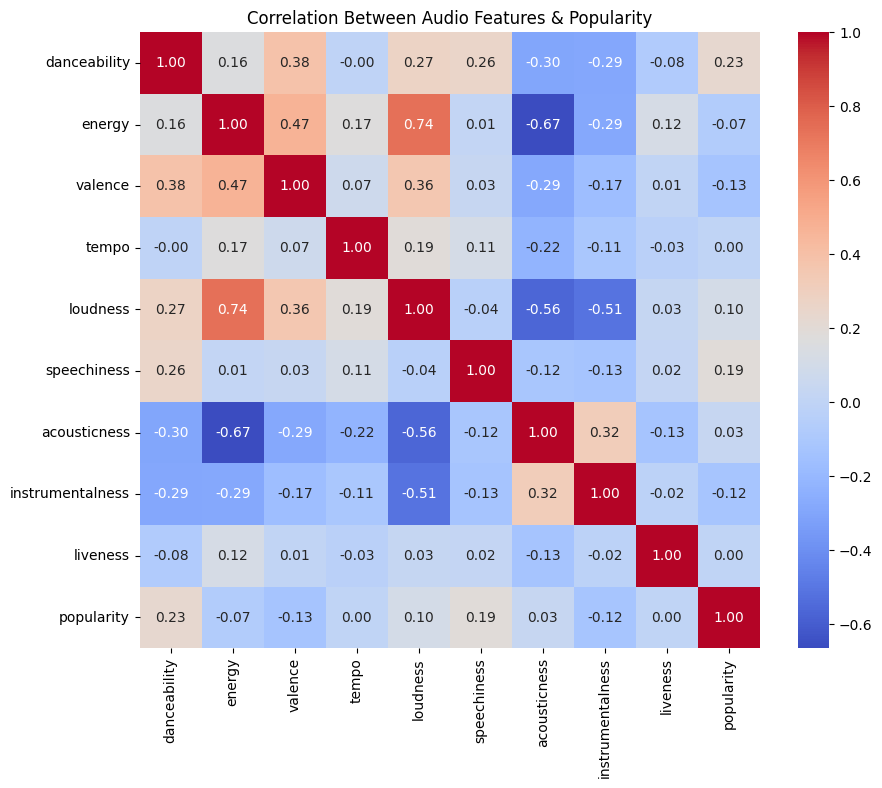

In [7]:
plt.figure(figsize=(10,8))
sns.heatmap(
    feature_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)
plt.title("Correlation Between Audio Features & Popularity")
plt.show()


In [8]:
feature_df["popularity_group"] = pd.qcut(
    feature_df["popularity"],
    q=3,
    labels=["Low", "Medium", "High"]
)


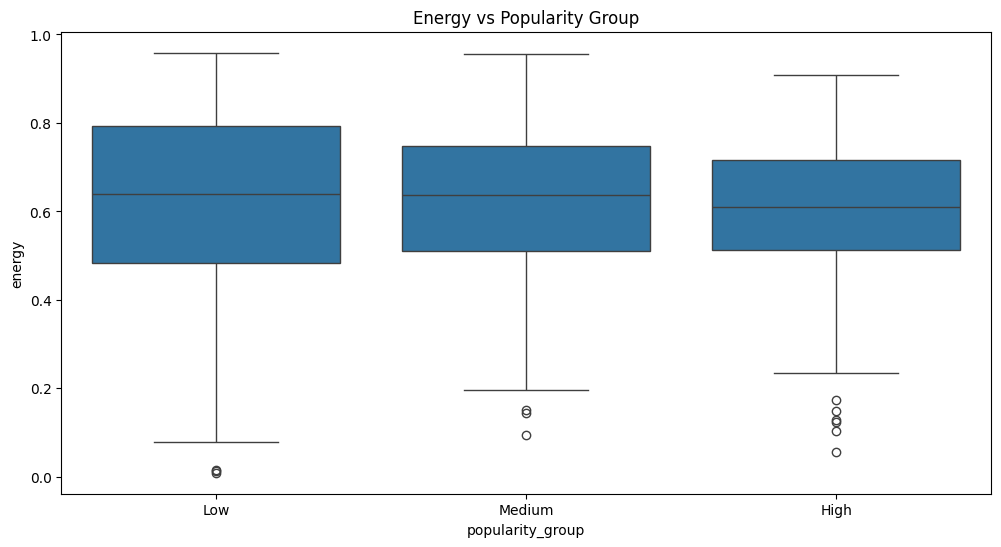

In [9]:
plt.figure(figsize=(12,6))
sns.boxplot(
    data=feature_df,
    x="popularity_group",
    y="energy"
)
plt.title("Energy vs Popularity Group")
plt.show()


In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(feature_df[audio_features])


In [11]:
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    pca_components,
    columns=["PC1", "PC2"]
)
pca_df["popularity"] = feature_df["popularity"].values


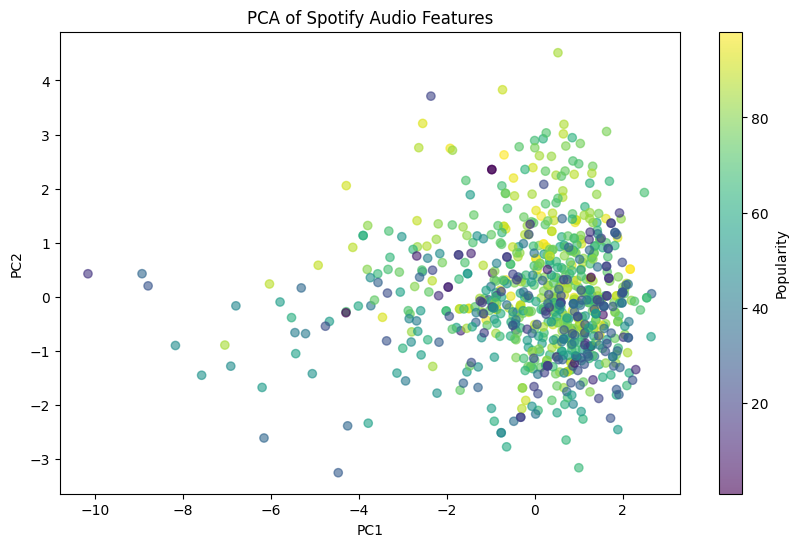

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["popularity"],
    cmap="viridis",
    alpha=0.6
)
plt.colorbar(label="Popularity")
plt.title("PCA of Spotify Audio Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()


In [13]:
pca_df.to_csv(
    r"D:\spotify\data\processed\analytics_ready\audio_feature_pca.csv",
    index=False
)
